# The Eigenbasis

*Course notes for **Math for Machine Learning**, C1 · W4 · L2 · V03 — "The Eigenbasis" (DeepLearning.AI).*

Some bases are more useful than others — and there's **one basis to rule them all**, the **eigenbasis**. It's the key to many machine-learning tools, especially **PCA**. In an eigenbasis a linear transformation reduces to nothing but **stretching along fixed directions**. We cover:

- How a matrix acts on the standard basis (a change of coordinates).
- A **special basis** in which the transformation only **stretches** — the eigenbasis.
- **Eigenvectors** (the special directions) and **eigenvalues** (the stretch factors), and why they simplify everything.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The transformation on the standard basis

Take $A = \begin{pmatrix} 2 & 1 \\ 0 & 3 \end{pmatrix}$. On the standard basis:

$$ (1,0) \mapsto (2,0), \qquad (0,1) \mapsto (1,3). $$

The unit square becomes a parallelogram — a **change of coordinates**, as you've seen before. Nothing special yet: the square's edges get tilted.

In [2]:
A = np.array([[2, 1],
              [0, 3]])
print('(1,0) ->', A @ np.array([1, 0]))
print('(0,1) ->', A @ np.array([0, 1]))

(1,0) -> [2 0]
(0,1) -> [1 3]


## 2. A special basis: only stretching

The choice of the *square* was arbitrary. Pick instead the basis $(1,0)$ and $(1,1)$:

$$ (1,0) \mapsto (2,0), \qquad (1,1) \mapsto (3,3). $$

Something remarkable happens: each output is **parallel to its input** — $(2,0)$ points the same way as $(1,0)$, and $(3,3)$ the same way as $(1,1)$. The transformation simply **stretches** along these two directions:

- along $(1,0)$: stretched by a factor of **2**,
- along $(1,1)$: stretched by a factor of **3**.

A basis with this property — where the transformation only stretches, sending a parallelogram to one with **parallel sides** — is an **eigenbasis**.

In [3]:
v1 = np.array([1, 0])
v2 = np.array([1, 1])
print('A @ (1,0) =', A @ v1, ' = 2 * (1,0)  -> parallel, stretched by 2')
print('A @ (1,1) =', A @ v2, ' = 3 * (1,1)  -> parallel, stretched by 3')

A @ (1,0) = [2 0]  = 2 * (1,0)  -> parallel, stretched by 2
A @ (1,1) = [3 3]  = 3 * (1,1)  -> parallel, stretched by 3


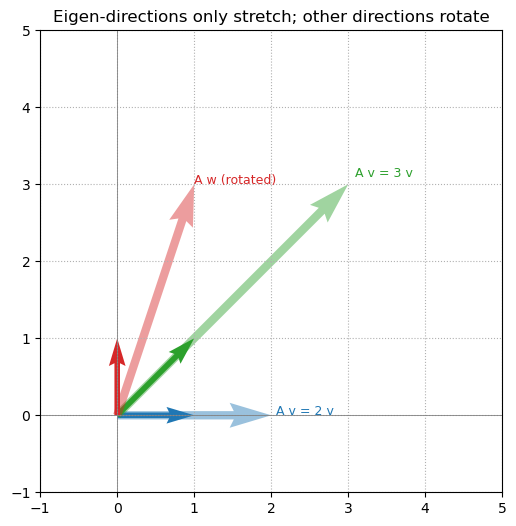

In [4]:
# Visualize: eigen-directions stay put (blue -> red, same line); an ordinary direction rotates
fig, ax = plt.subplots(figsize=(6, 6))
opts = dict(angles='xy', scale_units='xy', scale=1)
# eigenvectors and their images
for v, lam, c in [(v1, 2, 'C0'), (v2, 3, 'C2')]:
    ax.quiver(0, 0, *v, color=c, width=0.012, **opts)
    ax.quiver(0, 0, *(A @ v), color=c, alpha=0.45, width=0.018, **opts)
    ax.text(*(A @ v * 1.03), f'A v = {lam} v', color=c, fontsize=9)
# an ordinary vector that changes direction
w = np.array([0, 1])
ax.quiver(0, 0, *w, color='C3', width=0.012, **opts)
ax.quiver(0, 0, *(A @ w), color='C3', alpha=0.45, width=0.018, **opts)
ax.text(*(A @ w), 'A w (rotated)', color='C3', fontsize=9)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_title('Eigen-directions only stretch; other directions rotate')
plt.show()

## 3. Eigenvectors and eigenvalues

The special basis vectors are the **eigenvectors**, and their stretch factors are the **eigenvalues**. Here:

$$ A\,(1,0) = 2\,(1,0), \qquad A\,(1,1) = 3\,(1,1). $$

In general an eigenvector $v$ with eigenvalue $\lambda$ satisfies

$$ A v = \lambda v, $$

i.e. multiplying by the matrix is the **same as multiplying by a number** — for that special direction. NumPy finds them with `np.linalg.eig`:

In [5]:
eigvals, eigvecs = np.linalg.eig(A)
print('eigenvalues :', eigvals)                 # 2 and 3
print('eigenvectors (columns, normalized):')
print(eigvecs)
print()
# the eigenvectors point along (1,0) and (1,1) (up to scaling / sign)
for i in range(2):
    v = eigvecs[:, i]; lam = eigvals[i]
    print(f'A @ v = {A @ v}   lambda * v = {lam * v}   (equal)')

eigenvalues : [2. 3.]
eigenvectors (columns, normalized):
[[1.    0.707]
 [0.    0.707]]

A @ v = [2. 0.]   lambda * v = [2. 0.]   (equal)
A @ v = [2.121 2.121]   lambda * v = [2.121 2.121]   (equal)


## 4. Why it's useful: transformation becomes stretching

To find where $A$ sends the point $(3, 2)$ you could just multiply: $A\,(3,2) = (8, 6)$. But in the **eigenbasis** it's easier. Write $(3,2)$ in the eigenbasis:

$$ (3, 2) = 1\cdot(1,0) + 2\cdot(1,1). $$

Then applying $A$ is just **stretch each eigen-component by its eigenvalue** ($2$ and $3$):

$$ A(3,2) = 1\cdot 2\cdot(1,0) + 2\cdot 3\cdot(1,1) = (2,0) + (6,6) = (8,6). $$

No matrix multiply — just two scalings. That is the power of eigenvectors and eigenvalues: they turn a tangled transformation into independent stretches.

In [6]:
p = np.array([3, 2])
print('direct:  A @ (3,2) =', A @ p)

# eigenbasis coordinates: p = c1*(1,0) + c2*(1,1)
c1, c2 = np.linalg.solve(np.column_stack([v1, v2]), p)
print('coords in eigenbasis: c1 =', c1, ' c2 =', c2)

# apply A = stretch each component by its eigenvalue (2 and 3)
image = c1 * 2 * v1 + c2 * 3 * v2
print('via stretching:       ', image, ' (= (8,6))')

direct:  A @ (3,2) = [8 6]
coords in eigenbasis: c1 = 1.0  c2 = 2.0
via stretching:        [8. 6.]  (= (8,6))


## Summary

- An **eigenbasis** is a special basis in which a linear transformation is nothing but **stretching along fixed directions** — the image parallelogram has sides **parallel** to the original.
- The basis directions are **eigenvectors**; their stretch factors are **eigenvalues**, satisfying $A v = \lambda v$ (matrix multiply $=$ scalar multiply for that direction).
- For $A = \begin{pmatrix} 2 & 1 \\ 0 & 3 \end{pmatrix}$: eigenvectors $(1,0), (1,1)$ with eigenvalues $2, 3$.
- Eigenvectors **simplify** computation: express a point in the eigenbasis, then just **scale each component by its eigenvalue**. This is the foundation for **PCA** and many ML methods.
- In NumPy: `eigvals, eigvecs = np.linalg.eig(A)`.